# NB04: 카드매출 집계 및 배달수요 프록시 지수 산출

**목적**: 36개월 카드매출 CSV를 동별/업종별/시간대별로 집계하고, **배달수요 프록시 지수(delivery-demand proxy index)** 를 산출한다.

> ⚠️ **중요 해석 주의**: 이 지수는 카드결제 매출/건수 기반 프록시이다.  
> 실제 배달 주문 건수가 아닌 배달 가능성이 높은 업종의 거래 패턴을 반영하므로, 직접 배달 주문량으로 해석해서는 안 된다.

**입력**: `00_data/민간데이터/10. 매출(대민)(day)-*/10. 매출(대민)(day)/tbsh_gyeonggi_day_*.csv`  
**출력**:
- `processed/card_sales_agg.parquet` — 동별/업종별/시간대별 월간 집계
- `processed/card_hourly_demand.parquet` — 동별 시간대 배달수요 패턴
- `processed/card_delivery_demand.parquet` — 동별 배달수요 프록시 지수

**참조 시간대 매핑 (카드10 대민 공식 기준, 붙임4 민간데이터 제공 안내서)**:

| hour 코드 | 시간 범위 | 비고 |
|-----------|-----------|------|
| 01 | 00:00~06:59 | 심야/새벽 |
| 02 | 07:00~08:59 | 출근 전 |
| 03 | 09:00~10:59 | 오전 |
| 04 | 11:00~12:59 | **점심 피크** |
| 05 | 13:00~14:59 | **점심 피크** |
| 06 | 15:00~16:59 | 오후 |
| 07 | 17:00~18:59 | **저녁 피크** |
| 08 | 19:00~20:59 | **저녁 피크** |
| 09 | 21:00~22:59 | 야간 |
| 10 | 23:00~23:59 | 심야 |

In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path(r'C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset')
RAW  = BASE / '00_data'
OUT  = BASE / 'processed'
OUT.mkdir(exist_ok=True)

REQUIRED_COLS = [
    'ta_ymd', 'cty_rgn_no', 'admi_cty_no',
    'card_tpbuz_cd', 'card_tpbuz_nm_1', 'card_tpbuz_nm_2',
    'hour', 'sex', 'age', 'day', 'amt', 'cnt',
]
print('설정 완료')

설정 완료


## 1. 공식 시간대 매핑 & 업종 분류 정의

### 시간대 (hour) 공식 매핑
참조 NB04는 hour를 2시간 단위 등간격으로 가정했으나, 공식 자료에 따르면:  
- **hour 01**: 7시간 구간 (00:00~06:59) — 새벽 전체
- **hour 02~09**: 각 2시간 구간
- **hour 10**: 1시간 구간 (23:00~23:59)

따라서 점심/저녁 피크는 **04·05** (11~14시) 및 **07·08** (17~20시)이며,  
참조 NB04가 사용한 hour 6~7 (= 실제 15~18시)은 오후~이른저녁으로 피크가 아니다.

### 업종 분류 3단계
| 구분 | 설명 | 신호 강도 |
|------|------|----------|
| `direct_delivery` | 음식배달서비스 (L2) | 가장 강한 직접 배달 신호 |
| `meal_food` | 배달 가능 음식업종 (한식/중식 등) | 잠재적 배달 수요 |
| `retail_delivery` | 배달 가능 소매업종 (편의점/마트 등) | 약한 배달 신호 |
| `other` | 나머지 | 배달 무관 |

In [2]:
# ── 공식 시간대 매핑 ────────────────────────────────────────────
HOUR_MAP = {
    '01': dict(label='00:00~06:59', start=0,  end=6,  is_lunch=False, is_dinner=False, is_late=True),
    '02': dict(label='07:00~08:59', start=7,  end=8,  is_lunch=False, is_dinner=False, is_late=False),
    '03': dict(label='09:00~10:59', start=9,  end=10, is_lunch=False, is_dinner=False, is_late=False),
    '04': dict(label='11:00~12:59', start=11, end=12, is_lunch=True,  is_dinner=False, is_late=False),
    '05': dict(label='13:00~14:59', start=13, end=14, is_lunch=True,  is_dinner=False, is_late=False),
    '06': dict(label='15:00~16:59', start=15, end=16, is_lunch=False, is_dinner=False, is_late=False),
    '07': dict(label='17:00~18:59', start=17, end=18, is_lunch=False, is_dinner=True,  is_late=False),
    '08': dict(label='19:00~20:59', start=19, end=20, is_lunch=False, is_dinner=True,  is_late=False),
    '09': dict(label='21:00~22:59', start=21, end=22, is_lunch=False, is_dinner=False, is_late=False),
    '10': dict(label='23:00~23:59', start=23, end=23, is_lunch=False, is_dinner=False, is_late=True),
}
VALID_HOUR_CODES = set(HOUR_MAP.keys())

# ── 업종 분류 정의 ────────────────────────────────────────────────
# 1순위: 음식배달서비스 → direct_delivery
DIRECT_DELIVERY_L2 = {'음식배달서비스'}

# 2순위: 배달 가능 음식업종 → meal_food
MEAL_FOOD_L2 = {
    '한식', '분식', '패스트푸드', '고기요리', '일식/수산물',
    '닭/오리요리', '별식/퓨전요리', '중식', '양식',
    '커피/음료', '제과/제빵/떡/케익',
}

# 3순위: 배달 가능 소매업종 → retail_delivery
RETAIL_DELIVERY_L2 = {'종합소매점', '음/식료품소매', '건강/기호식품'}

def classify_delivery(nm1: str, nm2: str) -> str:
    """업종명으로 배달 관련 분류 반환 (우선순위: direct > meal > retail > other)."""
    if nm2 in DIRECT_DELIVERY_L2:
        return 'direct_delivery'
    if nm1 == '음식' and nm2 in MEAL_FOOD_L2:
        return 'meal_food'
    if nm1 == '소매/유통' and nm2 in RETAIL_DELIVERY_L2:
        return 'retail_delivery'
    return 'other'

print('공식 시간대 매핑:')
for code, info in HOUR_MAP.items():
    flags = []
    if info['is_lunch']: flags.append('점심피크')
    if info['is_dinner']: flags.append('저녁피크')
    if info['is_late']:  flags.append('심야')
    print(f"  hour {code} = {info['label']}  {'  '.join(flags)}")

공식 시간대 매핑:
  hour 01 = 00:00~06:59  심야
  hour 02 = 07:00~08:59  
  hour 03 = 09:00~10:59  
  hour 04 = 11:00~12:59  점심피크
  hour 05 = 13:00~14:59  점심피크
  hour 06 = 15:00~16:59  
  hour 07 = 17:00~18:59  저녁피크
  hour 08 = 19:00~20:59  저녁피크
  hour 09 = 21:00~22:59  
  hour 10 = 23:00~23:59  심야


## 2. CSV 파일 탐색 및 유효성 검증

In [3]:
# 카드매출 CSV 전체 탐색
card_files = sorted(glob.glob(
    str(RAW / '민간데이터' / '10. 매출(대민)(day)-*' / '10. 매출(대민)(day)' / 'tbsh_gyeonggi_day_*.csv')
))

if not card_files:
    raise FileNotFoundError(
        '카드매출 CSV 파일을 찾을 수 없습니다.\n'
        f'탐색 경로: {RAW}/민간데이터/10. 매출(대민)(day)-*/10. 매출(대민)(day)/tbsh_gyeonggi_day_*.csv'
    )

print(f'발견된 CSV 파일: {len(card_files)}개')

# 파일명에서 YYMM 추출 및 정렬 확인
yymms = []
for fp in card_files:
    stem = Path(fp).stem  # tbsh_gyeonggi_day_2305_성남시
    parts = stem.split('_')
    yymm = next((p for p in parts if len(p) == 4 and p.isdigit()), None)
    yymms.append(yymm)

yymms_sorted = sorted(set(y for y in yymms if y))
print(f'기간: {yymms_sorted[0]} (20{yymms_sorted[0][:2]}년 {yymms_sorted[0][2:]}월) '
      f'~ {yymms_sorted[-1]} (20{yymms_sorted[-1][:2]}년 {yymms_sorted[-1][2:]}월)')
print(f'개월 수: {len(yymms_sorted)}')
print(f'월 목록: {yymms_sorted}')

발견된 CSV 파일: 36개
기간: 2301 (2023년 01월) ~ 2512 (2025년 12월)
개월 수: 36
월 목록: ['2301', '2302', '2303', '2304', '2305', '2306', '2307', '2308', '2309', '2310', '2311', '2312', '2401', '2402', '2403', '2404', '2405', '2406', '2407', '2408', '2409', '2410', '2411', '2412', '2501', '2502', '2503', '2504', '2505', '2506', '2507', '2508', '2509', '2510', '2511', '2512']


## 3. CSV 로드 함수 정의

- 인코딩: `cp949` → `utf-8` → `euc-kr` 순서로 시도
- 구분자: 파이프(`|`) vs 쉼표(`,`) 자동 감지
- `hour` 컬럼: 정수로 저장된 경우 `zfill(2)`로 두 자리 문자열 정규화

In [4]:
def read_card_csv(fpath: str) -> pd.DataFrame:
    """카드매출 CSV를 인코딩/구분자 자동 감지 후 로드."""
    for enc in ('cp949', 'utf-8', 'euc-kr'):
        try:
            with open(fpath, 'r', encoding=enc) as f:
                first_line = f.readline()
            sep = '|' if '|' in first_line else ','
            df = pd.read_csv(fpath, encoding=enc, sep=sep, dtype=str, low_memory=False)
            # 컬럼명 공백 제거
            df.columns = df.columns.str.strip()
            return df
        except (UnicodeDecodeError, UnicodeError):
            continue
    raise ValueError(f'인코딩 감지 실패: {fpath}')


def validate_and_enrich(df: pd.DataFrame, fpath: str) -> pd.DataFrame:
    """컬럼 검증, 타입 변환, 파생 컬럼 추가."""
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f'필수 컬럼 누락 in {Path(fpath).name}: {missing}')

    # 숫자 컬럼 변환
    df['amt'] = pd.to_numeric(df['amt'], errors='coerce').fillna(0).astype('int64')
    df['cnt'] = pd.to_numeric(df['cnt'], errors='coerce').fillna(0).astype('int64')
    df['admi_cty_no'] = pd.to_numeric(df['admi_cty_no'], errors='coerce').astype('Int64')

    # 날짜 파생 컬럼
    df['ta_ymd'] = pd.to_datetime(df['ta_ymd'], format='%Y%m%d', errors='coerce')
    df['ym']           = df['ta_ymd'].dt.strftime('%y%m')  # YYMM (e.g. '2305')
    df['year']         = df['ta_ymd'].dt.year
    df['month']        = df['ta_ymd'].dt.month
    df['weekday_code'] = df['ta_ymd'].dt.weekday  # 0=월 ~ 6=일

    # hour: 두 자리 문자열 정규화 ('4' → '04')
    df['hour_code'] = df['hour'].astype(str).str.strip().str.zfill(2)

    # 유효하지 않은 hour 코드 경고
    invalid_hours = df[~df['hour_code'].isin(VALID_HOUR_CODES)]['hour_code'].unique()
    if len(invalid_hours) > 0:
        print(f'  ⚠ 비정상 hour 코드 in {Path(fpath).name}: {invalid_hours}')

    # 시간대 파생 컬럼 (공식 매핑 적용)
    df['hour_label']    = df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('label', '알수없음'))
    df['hour_start']    = df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('start', -1))
    df['hour_end']      = df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('end', -1))
    df['is_lunch_peak'] = df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('is_lunch', False))
    df['is_dinner_peak']= df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('is_dinner', False))
    df['is_late_night'] = df['hour_code'].map(lambda c: HOUR_MAP.get(c, {}).get('is_late', False))

    # 업종 분류
    df['delivery_type'] = df.apply(
        lambda r: classify_delivery(str(r['card_tpbuz_nm_1']), str(r['card_tpbuz_nm_2'])),
        axis=1
    )

    return df

print('로드 함수 정의 완료')

로드 함수 정의 완료


## 4. 전체 CSV 로드

In [5]:
%%time
parts = []
for i, fpath in enumerate(card_files):
    df = read_card_csv(fpath)
    df = validate_and_enrich(df, fpath)
    parts.append(df)
    if (i + 1) % 6 == 0 or i == len(card_files) - 1:
        print(f'  {i+1}/{len(card_files)} 파일 처리 완료  rows_so_far={sum(len(p) for p in parts):,}')

df_all = pd.concat(parts, ignore_index=True)
print(f'\n전체 로드 완료: {len(df_all):,} rows  |  메모리: {df_all.memory_usage(deep=True).sum()/1e6:.0f} MB')

  6/36 파일 처리 완료  rows_so_far=14,527,694
  12/36 파일 처리 완료  rows_so_far=28,873,717
  18/36 파일 처리 완료  rows_so_far=43,055,622
  24/36 파일 처리 완료  rows_so_far=58,004,987
  30/36 파일 처리 완료  rows_so_far=72,576,901
  36/36 파일 처리 완료  rows_so_far=87,265,541

전체 로드 완료: 87,265,541 rows  |  메모리: 64893 MB
CPU times: total: 23min 16s
Wall time: 23min 43s


## 5. QA / 유효성 검증

In [6]:
print('=' * 55)
print('QA 검증 요약')
print('=' * 55)
print(f'  총 행수:         {len(df_all):>12,}')
print(f'  총 파일:         {len(card_files):>12,}')
print(f'  고유 월(ym):     {df_all["ym"].nunique():>12}  ({df_all["ym"].min()} ~ {df_all["ym"].max()})')
print(f'  고유 행정동:     {df_all["admi_cty_no"].nunique():>12}')
print(f'  ta_ymd 결측:    {df_all["ta_ymd"].isna().sum():>12}')
print(f'  amt 결측/음수:  {(df_all["amt"] < 0).sum():>12}')
print()

print('hour_code 분포:')
hc_dist = df_all.groupby('hour_code')[['amt','cnt']].sum().assign(
    amt_pct=lambda d: d['amt'] / d['amt'].sum() * 100
)
for code, row in hc_dist.iterrows():
    label = HOUR_MAP.get(code, {}).get('label', '?')
    flags = ''
    if HOUR_MAP.get(code, {}).get('is_lunch'): flags += ' ★점심'
    if HOUR_MAP.get(code, {}).get('is_dinner'): flags += ' ★저녁'
    print(f'  {code} ({label}): cnt={row["cnt"]:>12,}  amt_비중={row["amt_pct"]:5.1f}%{flags}')

# 유효하지 않은 hour 코드 확인
invalid_rows = df_all[~df_all['hour_code'].isin(VALID_HOUR_CODES)]
if len(invalid_rows) > 0:
    print(f'\n⚠ 비정상 hour 코드 rows: {len(invalid_rows):,}')
    print(invalid_rows['hour_code'].value_counts())
else:
    print('\n✓ 모든 hour 코드 유효 (01~10)')

print('\n업종 분류 분포 (delivery_type):')
dt_dist = df_all.groupby('delivery_type')[['amt','cnt']].sum()
dt_dist['amt_pct'] = dt_dist['amt'] / dt_dist['amt'].sum() * 100
print(dt_dist.sort_values('amt', ascending=False).to_string())

QA 검증 요약
  총 행수:           87,265,541
  총 파일:                   36
  고유 월(ym):               36  (2301 ~ 2512)
  고유 행정동:               50
  ta_ymd 결측:               0
  amt 결측/음수:             0

hour_code 분포:
  01 (00:00~06:59): cnt=507,722,343.0  amt_비중=  7.9%
  02 (07:00~08:59): cnt=313,909,136.0  amt_비중=  4.2%
  03 (09:00~10:59): cnt=905,504,522.0  amt_비중= 13.9%
  04 (11:00~12:59): cnt=811,619,279.0  amt_비중= 13.9% ★점심
  05 (13:00~14:59): cnt=710,426,361.0  amt_비중= 12.7% ★점심
  06 (15:00~16:59): cnt=649,983,564.0  amt_비중= 11.6%
  07 (17:00~18:59): cnt=705,174,936.0  amt_비중= 11.1% ★저녁
  08 (19:00~20:59): cnt=658,955,422.0  amt_비중= 10.5% ★저녁
  09 (21:00~22:59): cnt=600,000,516.0  amt_비중= 10.0%
  10 (23:00~23:59): cnt=253,511,197.0  amt_비중=  4.3%

✓ 모든 hour 코드 유효 (01~10)

업종 분류 분포 (delivery_type):
                             amt         cnt    amt_pct
delivery_type                                          
other            279230850867607  5374140868  95.130330
retail_delivery    738392

In [7]:
print('매출 상위 업종 (card_tpbuz_nm_2, 전체 기간):')
top_cat = (
    df_all.groupby(['card_tpbuz_nm_1', 'card_tpbuz_nm_2'])[['amt', 'cnt']].sum()
    .sort_values('amt', ascending=False)
    .head(20)
)
top_cat['amt_억'] = top_cat['amt'] / 1e8
print(top_cat[['amt_억', 'cnt']].to_string(float_format='{:.1f}'.format))

매출 상위 업종 (card_tpbuz_nm_2, 전체 기간):
                                    amt_억         cnt
card_tpbuz_nm_1 card_tpbuz_nm_2                      
미디어/통신          인터넷쇼핑           1560936.5  2894825794
생활서비스           전문서비스            664786.2  1241263772
소매/유통           가전제품             142290.1   189402261
생활서비스           세탁/가사서비스         128628.3   482882679
소매/유통           인테리어/가정용품        115633.1   203083684
                종합소매점             59284.7   387766101
의료/건강           일반병원              35398.8    49028939
음식              한식                32337.8    87508656
의료/건강           의약/의료품            13791.4    48651245
소매/유통           의복/의류             13625.6    29568146
                음/식료품소매           13599.2    44297133
의료/건강           특화병원              11787.2     9899377
생활서비스           연료판매              11158.1    22247539
                차량관리/서비스           8163.8    29697814
학문/교육           입시학원               7411.4     2327749
음식              커피/음료              6808.6    78

## 6. 월간 집계 → `card_sales_agg.parquet`

행 단위 원본 데이터를 **(ym, admi_cty_no, card_tpbuz_nm_1, card_tpbuz_nm_2, hour_code, hour_label)** 기준으로 집계한다.

In [8]:
GROUP_COLS_SALES = [
    'ym', 'admi_cty_no',
    'card_tpbuz_nm_1', 'card_tpbuz_nm_2',
    'hour_code', 'hour_label',
    'delivery_type',
    'is_lunch_peak', 'is_dinner_peak', 'is_late_night',
]

card_sales_agg = (
    df_all
    .groupby(GROUP_COLS_SALES, as_index=False, dropna=False)
    .agg(amt=('amt', 'sum'), cnt=('cnt', 'sum'))
)
card_sales_agg = card_sales_agg.sort_values(['ym', 'admi_cty_no', 'hour_code']).reset_index(drop=True)

out_path = OUT / 'card_sales_agg.parquet'
card_sales_agg.to_parquet(out_path, index=False)
print(f'저장: {out_path}')
print(f'  rows: {len(card_sales_agg):,}  |  {out_path.stat().st_size/1024:.0f} KB')
print(f'  기간: {card_sales_agg["ym"].min()} ~ {card_sales_agg["ym"].max()}')
card_sales_agg.head()

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\card_sales_agg.parquet
  rows: 801,757  |  7006 KB
  기간: 2301 ~ 2512


,ym,admi_cty_no,card_tpbuz_nm_1,card_tpbuz_nm_2,hour_code,hour_label,delivery_type,is_lunch_peak,is_dinner_peak,is_late_night,amt,cnt
0,2301,41131510,공공/기업/단체,기업,01,00:00~06:59,other,False,False,True,4548,2
1,2301,41131510,생활서비스,사우나/휴게시설,01,00:00~06:59,other,False,False,True,700520,58
2,2301,41131510,생활서비스,연료판매,01,00:00~06:59,other,False,False,True,29165932,728
3,2301,41131510,소매/유통,선물/완구,01,00:00~06:59,other,False,False,True,53485,2
4,2301,41131510,소매/유통,음/식료품소매,01,00:00~06:59,retail_delivery,False,False,True,3081244,182


## 7. 시간대별 배달수요 패턴 → `card_hourly_demand.parquet`

전체 기간 동안 배달 관련 업종(`direct_delivery` + `meal_food` + `retail_delivery`)의  
동별·시간대별 매출/건수 및 비율을 집계한다.

In [9]:
# 배달 관련 행만 필터링
df_del = df_all[df_all['delivery_type'] != 'other'].copy()

hourly_agg = (
    df_del
    .groupby(['admi_cty_no', 'hour_code', 'hour_label',
              'is_lunch_peak', 'is_dinner_peak', 'is_late_night'],
             as_index=False)
    .agg(total_del_amt=('amt', 'sum'), total_del_cnt=('cnt', 'sum'))
)

# 동별 총합 대비 시간대별 비율
dong_total_amt = hourly_agg.groupby('admi_cty_no')['total_del_amt'].transform('sum')
hourly_agg['hour_ratio'] = np.where(
    dong_total_amt > 0,
    hourly_agg['total_del_amt'] / dong_total_amt,
    0.0
)

out_path = OUT / 'card_hourly_demand.parquet'
hourly_agg.to_parquet(out_path, index=False)
print(f'저장: {out_path}')
print(f'  rows: {len(hourly_agg):,}  |  {out_path.stat().st_size/1024:.0f} KB')

print('\n전체 시간대별 배달 매출 비중 (전 동 합산):')
global_hourly = (
    hourly_agg
    .groupby(['hour_code','hour_label'])[['total_del_amt','total_del_cnt']].sum()
    .reset_index()
    .sort_values('hour_code')
)
global_hourly['amt_pct'] = global_hourly['total_del_amt'] / global_hourly['total_del_amt'].sum() * 100
print(global_hourly[['hour_code','hour_label','total_del_amt','amt_pct']].to_string(
    index=False, float_format='{:.1f}'.format))

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\card_hourly_demand.parquet
  rows: 500  |  17 KB

전체 시간대별 배달 매출 비중 (전 동 합산):
hour_code  hour_label  total_del_amt  amt_pct
       01 00:00~06:59   409840181773      2.9
       02 07:00~08:59   282460048178      2.0
       03 09:00~10:59   830429422606      5.8
       04 11:00~12:59  2291952460275     16.0
       05 13:00~14:59  2378772843135     16.6
       06 15:00~16:59  2040261600659     14.3
       07 17:00~18:59  2376809760851     16.6
       08 19:00~20:59  2350906786319     16.4
       09 21:00~22:59  1097297910005      7.7
       10 23:00~23:59   234944949345      1.6


## 8. 배달수요 프록시 지수 산출 → `card_delivery_demand.parquet`

### 방법론
1. **최근 12개월** 데이터만 사용 → 계절성·트렌드 편향 최소화
2. **log1p 변환** → 고밀도 분당구 동의 과대대표 억제
3. **1~99 백분위 클리핑 후 min-max 정규화** → 이상치 영향 제거
4. **5개 컴포넌트 가중합** → 배달 신호 강도 수준별 반영

### 컴포넌트별 가중치
| 컴포넌트 | 설명 | 가중치 |
|----------|------|-------|
| `direct_delivery_score` | 음식배달서비스 매출 | 0.35 |
| `meal_demand_score` | 배달가능 음식업종 매출 | 0.30 |
| `retail_delivery_score` | 배달가능 소매업종 매출 | 0.15 |
| `transaction_score` | 전체 배달관련 거래건수 | 0.15 |
| `temporal_concentration_score` | 점심+저녁 피크 집중도 | 0.05 |

In [10]:
# 최근 12개월 결정
all_ym = sorted(df_all['ym'].dropna().unique())
if len(all_ym) < 12:
    raise ValueError(f'최근 12개월 window를 구성할 수 없습니다. 보유 월수: {len(all_ym)}')

recent_yms  = all_ym[-12:]
recent_start = recent_yms[0]
recent_end   = recent_yms[-1]
print(f'최근 12개월: {recent_start} ~ {recent_end}')
print(f'  해당 월 목록: {recent_yms}')

df_recent = df_all[df_all['ym'].isin(recent_yms)].copy()
print(f'최근 12개월 rows: {len(df_recent):,}')

최근 12개월: 2501 ~ 2512
  해당 월 목록: ['2501', '2502', '2503', '2504', '2505', '2506', '2507', '2508', '2509', '2510', '2511', '2512']
최근 12개월 rows: 28,941,644


In [11]:
def clip_log1p_minmax(series: pd.Series, p_low: float = 1.0, p_high: float = 99.0) -> pd.Series:
    """log1p → 백분위 클리핑 → min-max 정규화 [0, 1]. 분산 0이면 0.5 반환."""
    s = np.log1p(series.clip(lower=0))
    lo = np.percentile(s.dropna(), p_low)
    hi = np.percentile(s.dropna(), p_high)
    if hi == lo:  # zero variance
        return pd.Series(0.5, index=series.index)
    return ((s - lo) / (hi - lo)).clip(0, 1)


# ── 동별 월평균 집계 (최근 12개월) ────────────────────────────────
n_months = 12

# 전체 배달 관련 매출/건수
df_del_recent = df_recent[df_recent['delivery_type'] != 'other']
base_agg = (
    df_del_recent
    .groupby('admi_cty_no')[['amt', 'cnt']].sum()
    .rename(columns={'amt': 'total_del_amt', 'cnt': 'total_del_cnt'})
    / n_months
).reset_index()
base_agg.columns = ['admi_cty_no', 'avg_monthly_del_amt', 'avg_monthly_del_cnt']

# 업종별 월평균
def monthly_avg_by_type(delivery_type_: str, col_name: str) -> pd.Series:
    return (
        df_recent[df_recent['delivery_type'] == delivery_type_]
        .groupby('admi_cty_no')['amt'].sum() / n_months
    ).rename(col_name)

direct_avg  = monthly_avg_by_type('direct_delivery',  'avg_monthly_direct_delivery_amt')
meal_avg    = monthly_avg_by_type('meal_food',         'avg_monthly_meal_amt')
retail_avg  = monthly_avg_by_type('retail_delivery',   'avg_monthly_retail_amt')

demand = (
    base_agg
    .set_index('admi_cty_no')
    .join(direct_avg, how='left')
    .join(meal_avg,   how='left')
    .join(retail_avg, how='left')
    .fillna(0)
    .reset_index()
)

# ── 피크 시간대 집중도 ────────────────────────────────────────────
# (점심+저녁 피크 배달 매출) / 전체 배달 매출
peak_amt = (
    df_del_recent[df_del_recent['is_lunch_peak'] | df_del_recent['is_dinner_peak']]
    .groupby('admi_cty_no')['amt'].sum()
    .rename('peak_del_amt')
)
all_del_amt = df_del_recent.groupby('admi_cty_no')['amt'].sum().rename('all_del_amt')
temporal = (peak_amt / all_del_amt.replace(0, np.nan)).fillna(0).rename('temporal_conc')
demand = demand.set_index('admi_cty_no').join(temporal, how='left').fillna(0).reset_index()

# ── 컴포넌트 점수 정규화 ──────────────────────────────────────────
demand['direct_delivery_score']       = clip_log1p_minmax(demand['avg_monthly_direct_delivery_amt'])
demand['meal_demand_score']           = clip_log1p_minmax(demand['avg_monthly_meal_amt'])
demand['retail_delivery_score']       = clip_log1p_minmax(demand['avg_monthly_retail_amt'])
demand['transaction_score']           = clip_log1p_minmax(demand['avg_monthly_del_cnt'])
demand['temporal_concentration_score']= demand['temporal_conc'].clip(0, 1)  # already [0,1]

# ── 최종 배달수요 프록시 지수 ────────────────────────────────────
demand['delivery_demand_index'] = (
    0.35 * demand['direct_delivery_score']
  + 0.30 * demand['meal_demand_score']
  + 0.15 * demand['retail_delivery_score']
  + 0.15 * demand['transaction_score']
  + 0.05 * demand['temporal_concentration_score']
)

demand['recent_month_start'] = recent_start
demand['recent_month_end']   = recent_end

demand = demand.sort_values('delivery_demand_index', ascending=False).reset_index(drop=True)

out_path = OUT / 'card_delivery_demand.parquet'
demand.to_parquet(out_path, index=False)
print(f'저장: {out_path}')
print(f'  rows: {len(demand)}  |  {out_path.stat().st_size/1024:.0f} KB')

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\card_delivery_demand.parquet
  rows: 50  |  15 KB


## 9. 결과 검증: 배달수요 프록시 지수 상위 15개 동

In [12]:
# 행정동 코드 → 이름 매핑 (crosswalk)
cw_path = OUT / 'admin_code_crosswalk.csv'
if cw_path.exists():
    cw = pd.read_csv(cw_path)
    code_to_name = dict(zip(cw['CSV_ADMI_CD'].astype('Int64'), cw['DONG_NM']))
else:
    code_to_name = {}
    print('⚠ admin_code_crosswalk.csv 없음 — 행정동코드로 표시')

demand['dong_nm'] = demand['admi_cty_no'].map(code_to_name).fillna(demand['admi_cty_no'].astype(str))

score_cols = [
    'dong_nm', 'delivery_demand_index',
    'direct_delivery_score', 'meal_demand_score',
    'retail_delivery_score', 'transaction_score',
    'temporal_concentration_score',
    'avg_monthly_direct_delivery_amt', 'avg_monthly_meal_amt',
]
print('▶ 배달수요 프록시 지수 상위 15개 동:')
print(demand[score_cols].head(15).to_string(
    index=False,
    float_format=lambda x: f'{x:.3f}' if abs(x) < 100 else f'{x:,.0f}'
))

▶ 배달수요 프록시 지수 상위 15개 동:
dong_nm  delivery_demand_index  direct_delivery_score  meal_demand_score  retail_delivery_score  transaction_score  temporal_concentration_score  avg_monthly_direct_delivery_amt  avg_monthly_meal_amt
   수내1동                  0.930                  0.940              0.937                  1.000              0.915                         0.641                        9,098,627        16,402,793,292
   정자1동                  0.895                  0.983              0.879                  0.795              0.907                         0.633                       18,925,600        12,059,243,472
   야탑1동                  0.886                  0.945              0.854                  0.875              0.897                         0.669                        9,877,543        10,596,374,324
   서현1동                  0.882                  0.806              1.000                  0.762              1.000                         0.707                          915,88

## 11. 시각화

### 11-1. 공식 시간대별 배달 매출 패턴

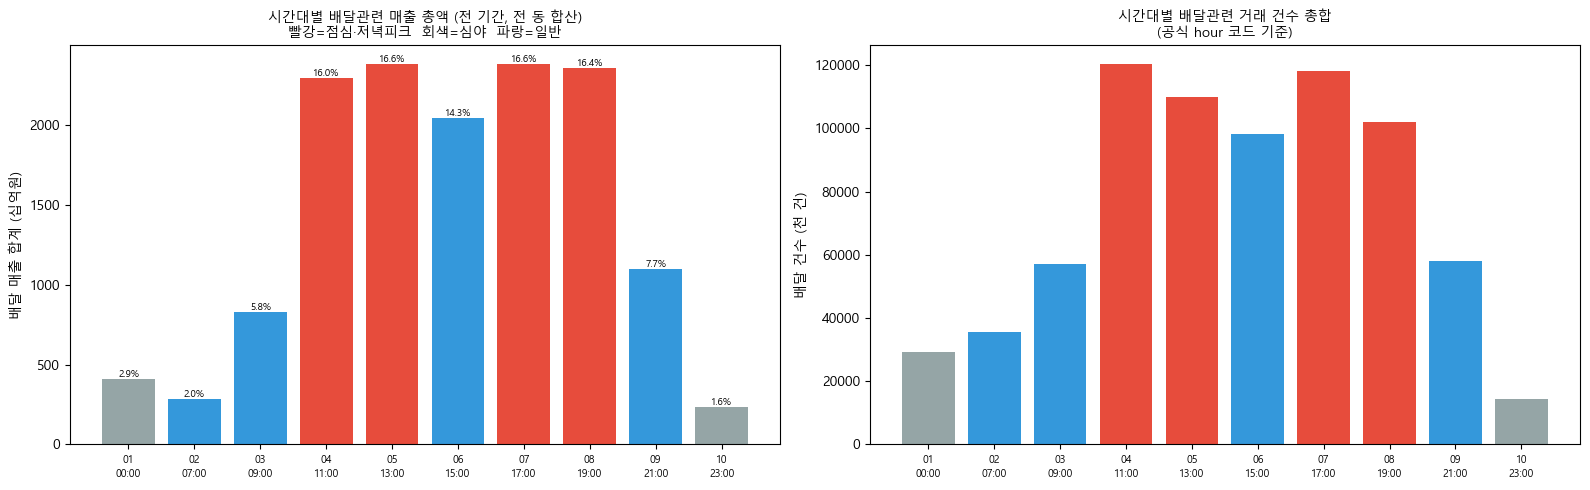

※ 구 방식은 hour 06~07을 피크로 보았으나, 공식 매핑상 06=15:00~16:59, 07=17:00~18:59임


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 시간대별 전체 배달 매출
gh = global_hourly.sort_values('hour_code')
colors = ['#e74c3c' if HOUR_MAP.get(c,{}).get('is_lunch') or HOUR_MAP.get(c,{}).get('is_dinner')
          else ('#95a5a6' if HOUR_MAP.get(c,{}).get('is_late') else '#3498db')
          for c in gh['hour_code']]

bars = axes[0].bar(range(len(gh)), gh['total_del_amt'] / 1e9, color=colors)
axes[0].set_xticks(range(len(gh)))
axes[0].set_xticklabels(
    [f"{r['hour_code']}\n{r['hour_label'][:5]}" for _, r in gh.iterrows()],
    fontsize=7.5
)
axes[0].set_ylabel('배달 매출 합계 (십억원)')
axes[0].set_title('시간대별 배달관련 매출 총액 (전 기간, 전 동 합산)\n'
                  '빨강=점심·저녁피크  회색=심야  파랑=일반', fontsize=10)
for bar, val in zip(bars, gh['amt_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

# 시간대별 건수 패턴
axes[1].bar(range(len(gh)), gh['total_del_cnt'] / 1e3, color=colors)
axes[1].set_xticks(range(len(gh)))
axes[1].set_xticklabels(
    [f"{r['hour_code']}\n{r['hour_label'][:5]}" for _, r in gh.iterrows()],
    fontsize=7.5
)
axes[1].set_ylabel('배달 건수 (천 건)')
axes[1].set_title('시간대별 배달관련 거래 건수 총합\n(공식 hour 코드 기준)', fontsize=10)

plt.tight_layout()
plt.show()
print('※ 구 방식은 hour 06~07을 피크로 보았으나, 공식 매핑상 06=15:00~16:59, 07=17:00~18:59임')

### 11-2. 상위 15개 동 배달수요 프록시 지수 + 컴포넌트 기여도

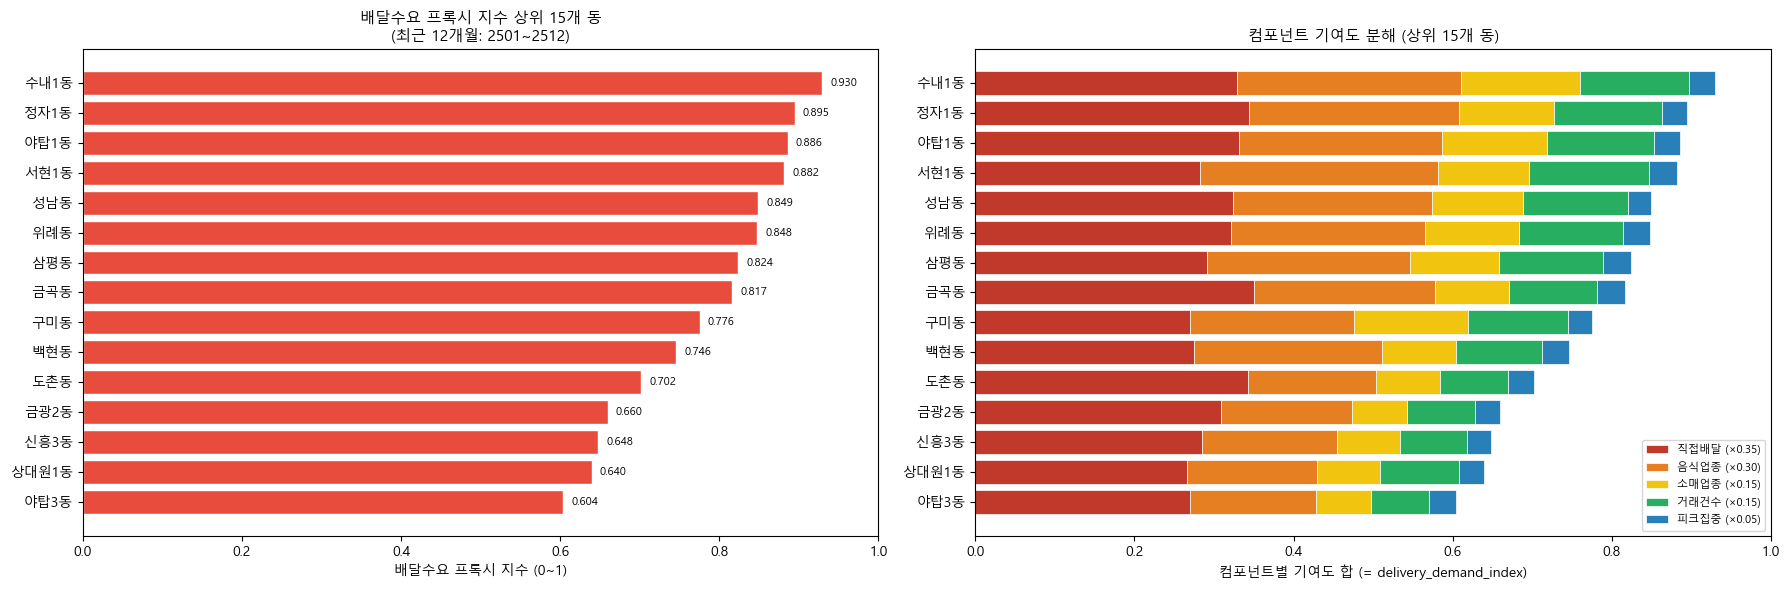

In [15]:
top15 = demand.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 왼쪽: 종합 지수 ─────────────────────────────────────────────
axes[0].barh(
    top15['dong_nm'][::-1],
    top15['delivery_demand_index'][::-1],
    color='#e74c3c', edgecolor='white'
)
axes[0].set_xlabel('배달수요 프록시 지수 (0~1)')
axes[0].set_title('배달수요 프록시 지수 상위 15개 동\n'
                  f'(최근 12개월: {recent_start}~{recent_end})', fontsize=11)
axes[0].set_xlim(0, 1)
for bar, val in zip(axes[0].patches, top15['delivery_demand_index'][::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

# ── 오른쪽: 컴포넌트 기여도 스택 바 ─────────────────────────────
component_weights = {
    'direct_delivery_score':        0.35,
    'meal_demand_score':            0.30,
    'retail_delivery_score':        0.15,
    'transaction_score':            0.15,
    'temporal_concentration_score': 0.05,
}
comp_labels = {
    'direct_delivery_score':        '직접배달 (×0.35)',
    'meal_demand_score':            '음식업종 (×0.30)',
    'retail_delivery_score':        '소매업종 (×0.15)',
    'transaction_score':            '거래건수 (×0.15)',
    'temporal_concentration_score': '피크집중 (×0.05)',
}
comp_colors = ['#c0392b','#e67e22','#f1c40f','#27ae60','#2980b9']

dongs = top15['dong_nm'].tolist()[::-1]
bottoms = np.zeros(len(dongs))
for (col, weight), color in zip(component_weights.items(), comp_colors):
    vals = (top15[col] * weight).values[::-1]
    axes[1].barh(dongs, vals, left=bottoms, color=color,
                 label=comp_labels[col], edgecolor='white', linewidth=0.5)
    bottoms += vals

axes[1].set_xlabel('컴포넌트별 기여도 합 (= delivery_demand_index)')
axes[1].set_title('컴포넌트 기여도 분해 (상위 15개 동)', fontsize=11)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 11-3. 구 방식 vs 신 방식 순위 비교

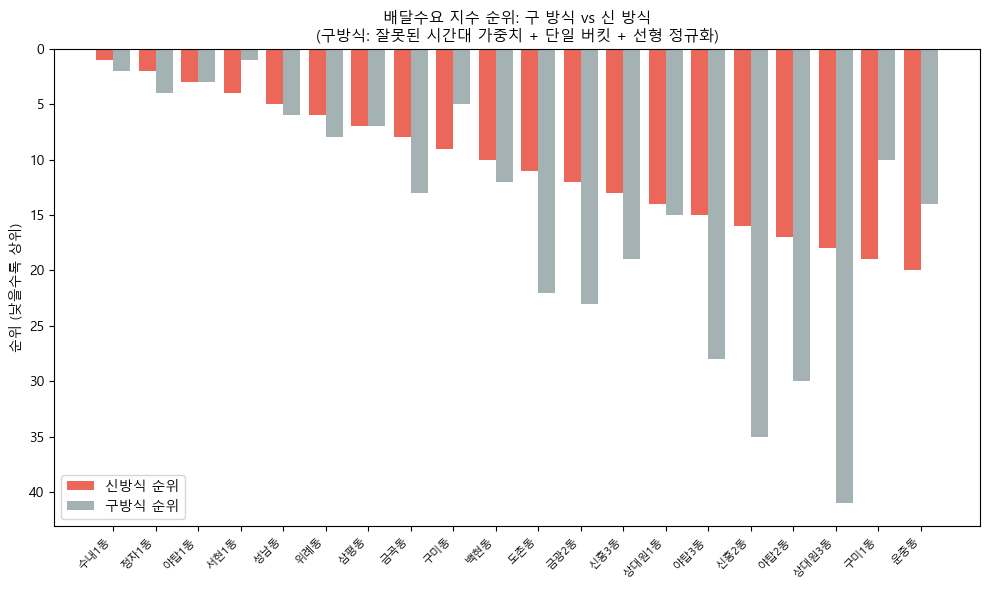

In [16]:
compare_top = rank_compare.sort_values('new_rank').head(20).copy()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(compare_top))
ax.bar(x - 0.2, compare_top['new_rank'], width=0.4, label='신방식 순위', color='#e74c3c', alpha=0.85)
ax.bar(x + 0.2, compare_top['old_rank'], width=0.4, label='구방식 순위', color='#95a5a6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_top['dong_nm'], rotation=45, ha='right', fontsize=8)
ax.invert_yaxis()  # 1위가 상단
ax.set_ylabel('순위 (낮을수록 상위)')
ax.set_title('배달수요 지수 순위: 구 방식 vs 신 방식\n'
             '(구방식: 잘못된 시간대 가중치 + 단일 버킷 + 선형 정규화)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

## 12. 최종 출력 요약

In [17]:
print('=' * 60)
print('NB04 출력 파일 요약')
print('=' * 60)
outputs = [
    (OUT / 'card_sales_agg.parquet',      '동별/업종별/시간대별 월간 집계'),
    (OUT / 'card_hourly_demand.parquet',   '동별 시간대 배달수요 패턴'),
    (OUT / 'card_delivery_demand.parquet', '동별 배달수요 프록시 지수'),
]
for path, desc in outputs:
    if path.exists():
        df_check = pd.read_parquet(path)
        print(f'  ✓ {path.name:<40s}  {path.stat().st_size/1024:>7.0f} KB  {len(df_check):>8,} rows  {desc}')
    else:
        print(f'  ✗ {path.name} — 파일 없음!')

print()
print(f'데이터 기간: {all_ym[0]} ~ {all_ym[-1]}  ({len(all_ym)}개월)')
print(f'지수 산출 기간: {recent_start} ~ {recent_end}  (최근 12개월)')
print(f'성남시 행정동: {demand["admi_cty_no"].nunique()}개')
print()
print('⚠ 배달수요 프록시 지수는 카드매출 기반 추정값입니다.')
print('  실제 배달 주문 건수와 직접 비교하거나 절대값으로 해석하지 마세요.')

NB04 출력 파일 요약
  ✓ card_sales_agg.parquet                       7006 KB   801,757 rows  동별/업종별/시간대별 월간 집계
  ✓ card_hourly_demand.parquet                     17 KB       500 rows  동별 시간대 배달수요 패턴
  ✓ card_delivery_demand.parquet                   15 KB        50 rows  동별 배달수요 프록시 지수

데이터 기간: 2301 ~ 2512  (36개월)
지수 산출 기간: 2501 ~ 2512  (최근 12개월)
성남시 행정동: 50개

⚠ 배달수요 프록시 지수는 카드매출 기반 추정값입니다.
  실제 배달 주문 건수와 직접 비교하거나 절대값으로 해석하지 마세요.
